In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json

In [2]:
voting_df = pd.read_csv('./cache/voting_term10.csv')

In [3]:
voting_df.columns

Index(['id', 'date', 'sitting', 'sittingDay', 'votingNumber', 'title', 'topic',
       'description', 'kind', 'totalVoted', 'notParticipating', 'yes', 'no',
       'abstain', 'votingOptions', 'votes', 'percentOfYes', 'percentOfNo',
       'percentOfAbstain', 'percentOfAbsent'],
      dtype='object')

In [4]:
percent_column_regex = re.compile('percentOf')
percent_columns = [ x for x in voting_df.columns.to_list() if percent_column_regex.match(x) ]

# Rodzaje głosowań

Istnieją dwa rodzaje głosowań, `ELECTRONIC` gdzie posłowie głosują `TAK` lub `NIE` oraz `ON_LIST` gdzie posłowie głosują na opcję z listy (żadną lub kilka).

In [5]:
voting_df.kind.value_counts()

kind
ELECTRONIC    1947
ON_LIST          6
Name: count, dtype: int64

In [6]:
list_voting_df = voting_df[voting_df.kind == 'ON_LIST']
list_voting_df = list_voting_df.reset_index(drop=True)

In [7]:
list_voting_df[['yes', 'no', 'abstain', 'notParticipating']]

,yes,no,abstain,notParticipating
0,0,0,0,1
1,0,0,0,3
2,0,0,0,33
3,0,0,0,40
4,0,0,0,27
5,0,0,0,35


In [8]:
list_votes = list_voting_df.loc[0].votes
list_votes_df = pd.DataFrame(json.loads(list_votes.replace("'", "\"")))

list_votes_df.listVotes.head(10)

0    {'1': 'NO', '2': 'YES'}
1    {'1': 'YES', '2': 'NO'}
2    {'1': 'NO', '2': 'YES'}
3    {'1': 'NO', '2': 'YES'}
4    {'1': 'NO', '2': 'YES'}
5    {'1': 'NO', '2': 'YES'}
6    {'1': 'NO', '2': 'YES'}
7    {'1': 'YES', '2': 'NO'}
8    {'1': 'NO', '2': 'YES'}
9    {'1': 'YES', '2': 'NO'}
Name: listVotes, dtype: object

Dla głosowań `ON_LIST` brakuje typowych głosów `TAK`/`NIE`/`WSTRZYMANO SIĘ`.\
Trzeba to brać pod uwagę w analizie rozkładu głosów.

# Rozkład głosów

## Statystyki opisowe procentów rozkładu głosów

In [9]:
voting_df[percent_columns].describe().drop('count', axis=0)

,percentOfYes,percentOfNo,percentOfAbstain,percentOfAbsent
mean,52.834501,42.547302,3.747552,6.614772
std,29.950139,29.203644,9.345740,4.332448
min,0.000000,0.000000,0.000000,0.220000
25%,41.460000,4.580000,0.000000,4.130000
50%,46.060000,52.550000,0.690000,6.090000
75%,60.530000,55.660000,3.630000,7.830000
max,100.000000,100.000000,58.240000,50.430000


Pamiętając o istnieniu głosowań typu `ON_LIST` które nie zawierają głosów `TAK`/`NIE`/`WSTRZYMANO SIĘ` należy sprawdzić jakie głosowania nie mają danego głosu aby wykluczyć przekłamanie z powodu występowania głosowania `ON_LIST`.

### Głosowania bez głosów `TAK` lub `NIE`

In [10]:
non_yes_no_df = voting_df[(voting_df.percentOfYes == 0) | (voting_df.percentOfNo == 0)]

In [11]:
non_yes_no_df.kind.value_counts()

kind
ELECTRONIC    324
ON_LIST         6
Name: count, dtype: int64

Istnieją "tradycyjne" głosowania bez głosów na `TAK` lub `NIE`

In [12]:
non_yes_no_df = non_yes_no_df[non_yes_no_df.kind == 'ELECTRONIC']

W danych o głosowaniach możemy znaleźć tytuł oraz temat głosowania.\
Sprawdzając tytuły i tematy głosowań możemy zidentyfikować które głosowania należy odrzucić żeby dokonać analizy głosowań na `TAK` lub `NIE`

Istnieją głosowania których tematem (kolumna topic) jest `Głosowanie kworum`. Kworum oznacza minimalną liczbę osób do podjęcia decyzji. Może to sugerować że w takim głosowaniu posłowie nie oddają głosu `TAK` lub `NIE`

In [13]:
len(voting_df[voting_df.topic == 'Głosowanie kworum'])

10

In [14]:
quorum_voting_df = voting_df[voting_df.topic == 'Głosowanie kworum']
quorum_voting_df = quorum_voting_df.reset_index(drop=True)

In [15]:
quorum_votes = quorum_voting_df.loc[0].votes
quorum_votes_df = pd.DataFrame(json.loads(quorum_votes.replace("'", "\"")))

quorum_votes_df.vote.unique()

array(['ABSENT', 'PRESENT'], dtype=object)

W głosowaniu kworum posłowie mogą oddać głos `OBECNY` albo być nieobecnym.\
Należy te głosowania wykluczyć z analizy głosowań `TAK` lub `NIE`.

In [16]:
non_list_voting_df = voting_df[voting_df.kind == 'ELECTRONIC']

In [17]:
yes_no_voting_df = non_list_voting_df[non_list_voting_df.topic != 'Głosowanie kworum']

## Wartości statystyczne poszczególnych głosów

Funckja `describe` zapewnia informacje o:
- count: Liczba niepustych wierszy (czyli liczba przeanalizowanych głosowań).
- mean: Średnia arytmetyczna (np. średni procent głosów na "tak" we wszystkich głosowaniach).
- std: Odchylenie standardowe, czyli miara tego, jak bardzo wyniki są "rozstrzelone" wokół średniej.
- min: Wartość minimalna (najniższy zanotowany procent głosów).
- 25%: Pierwszy kwartyl. 25% wyników było niższych lub równych tej wartości.
- 50%: Mediana. Dokładnie połowa wyników była niższa lub równa tej wartości. To środkowy wynik.
- 75%: Trzeci kwartyl. 75% wyników było niższych lub równych tej wartości.
- max: Wartość maksymalna (najwyższy zanotowany procent głosów).

### Wartości statystyczne procentów głosów `TAK` lub `NIE`

In [18]:
yes_no_voting_df[['percentOfYes', 'percentOfNo']].describe()

,percentOfYes,percentOfNo
count,1937.000000,1937.000000
mean,53.270924,42.898751
std,29.684398,29.065731
min,0.000000,0.000000
25%,41.510000,5.180000
50%,46.140000,52.670000
75%,62.440000,55.680000
max,100.000000,100.000000


### Wartości statystyczne procentów głosów `WSTRZYMANO SIĘ`

In [19]:
non_list_voting_df.percentOfAbstain.describe()

count    1947.000000
mean        3.759101
std         9.357816
min         0.000000
25%         0.000000
50%         0.690000
75%         3.640000
max        58.240000
Name: percentOfAbstain, dtype: float64

### Wartości statystyczne procentów głosów  `NIEOBECNY`

In [20]:
voting_df.percentOfAbsent.describe()

count    1953.000000
mean        6.614772
std         4.332448
min         0.220000
25%         4.130000
50%         6.090000
75%         7.830000
max        50.430000
Name: percentOfAbsent, dtype: float64

## Dystrybuanta głosów na głosowaniach

Wykres określa jaki procent głosowań zakończył się danym wynikiem.

Przykład:
Znajdź na osi poziomej 40%. Popatrz w górę do niebieskiej linii, a potem w lewo do osi pionowej. Wartość tam to około 0.2 (czyli 20%).
Co to oznacza? Że 20% wszystkich głosowań zakończyło się wynikiem 40% "na tak" lub mniej.

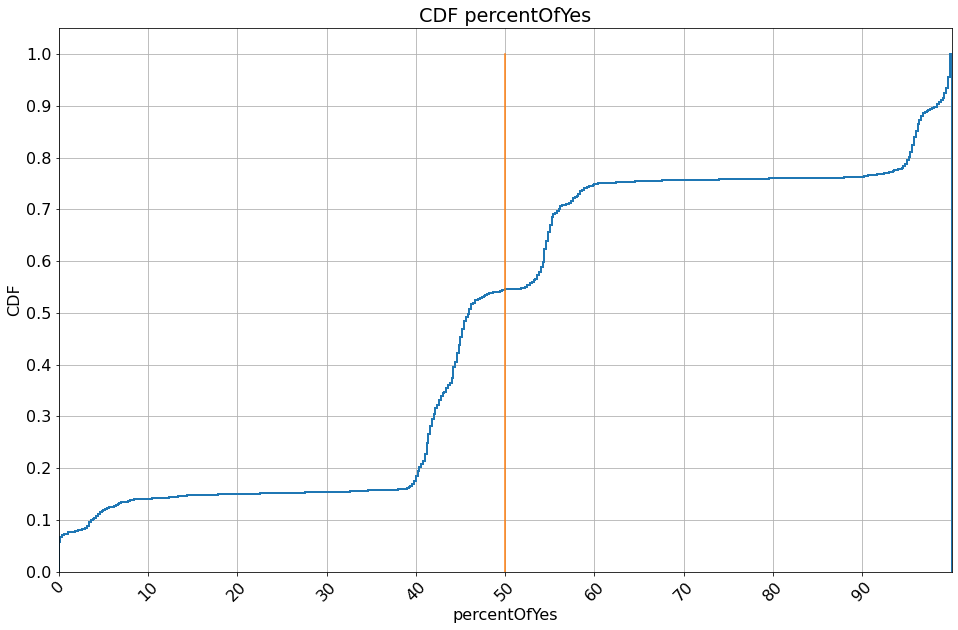

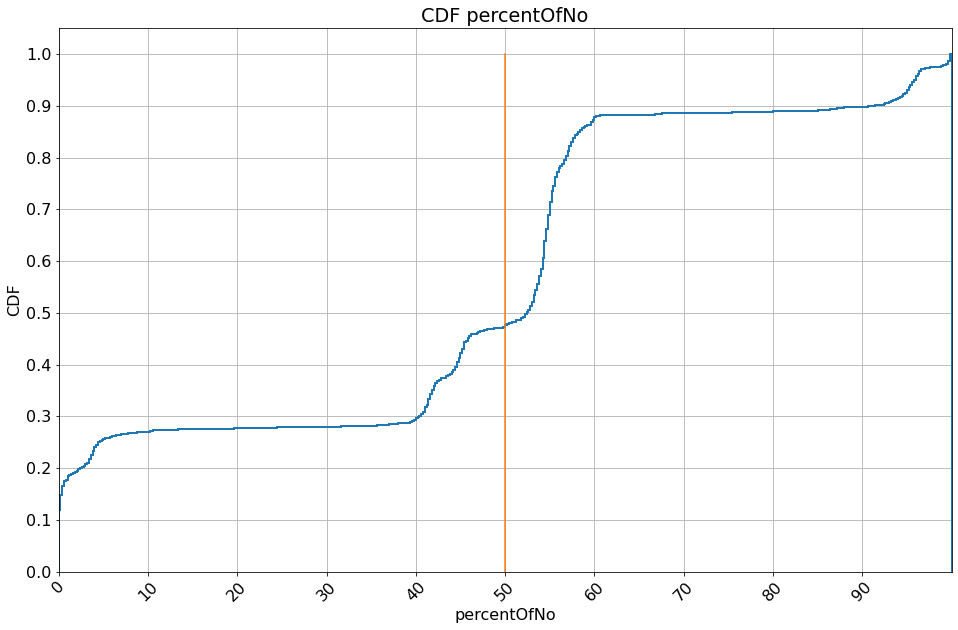

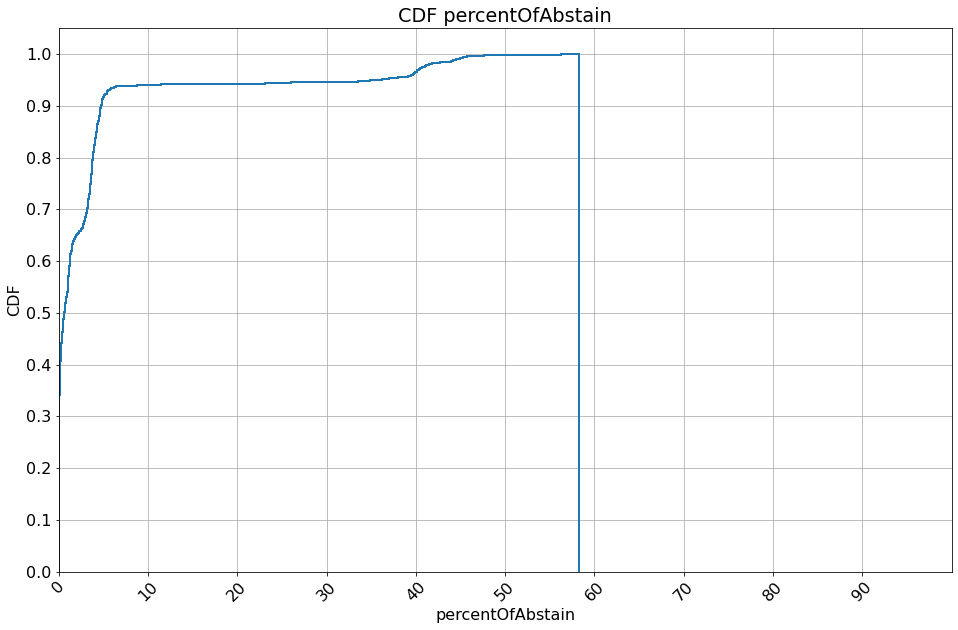

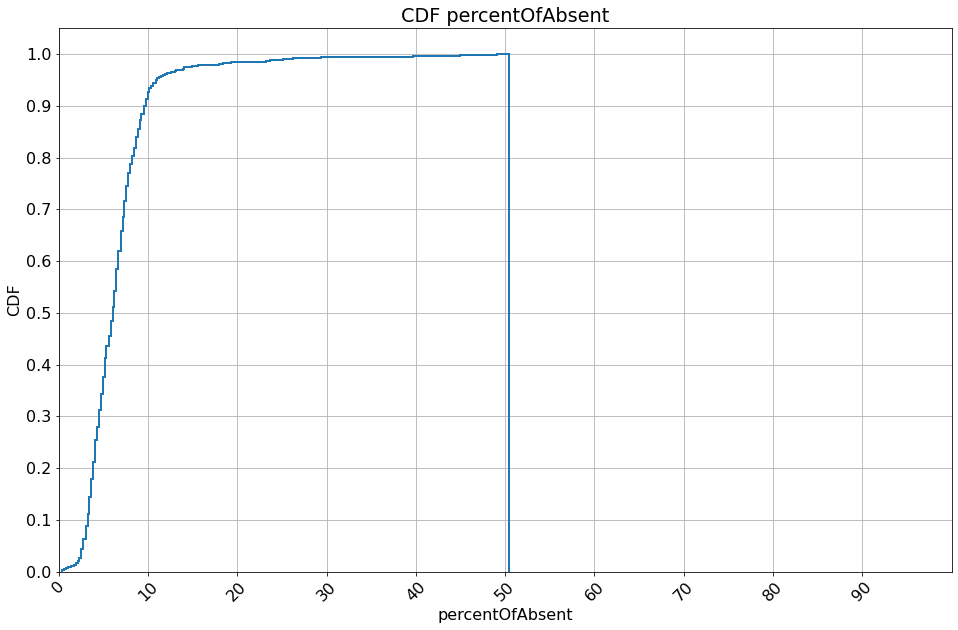

In [21]:
for column in percent_columns:
    plt.figure(figsize=(16,10))
    plt.rcParams.update(
        {'font.size': 16}
    )
    plt.hist(
        voting_df[column],
        bins=500,
        cumulative=True,
        density=True,
        histtype='step',
        linewidth=2
    )
    if ('Yes' in column) | ('No' in column):
        plt.plot([50,50], [0,1])
    plt.xticks(np.arange(0, 100, 10), np.arange(0, 100, 10), rotation=45)
    plt.yticks(np.arange(0, 1.1, 0.1), np.round(np.arange(0, 1.1, 0.1),1))
    plt.xlim(0,100)
    plt.grid(True)
    plt.title(f'CDF {column}')
    plt.xlabel(column)
    plt.ylabel('CDF')
    plt.show()